### Carga de datos 

In [1]:
import pandas as pd

In [2]:
df_train = pd.read_parquet("C:/Users/carlo/OneDrive/Documentos/repos/meli-ds/data/processed/df_train.parquet", engine="pyarrow")
df_test = pd.read_parquet("C:/Users/carlo/OneDrive/Documentos/repos/meli-ds/data/processed/df_test.parquet", engine="pyarrow")
df_oot = pd.read_parquet("C:/Users/carlo/OneDrive/Documentos/repos/meli-ds/data/processed/df_oot.parquet", engine="pyarrow")
df_oos = pd.read_parquet("C:/Users/carlo/OneDrive/Documentos/repos/meli-ds/data/processed/df_oos.parquet", engine="pyarrow")

In [3]:
varss = ['attribute4_change_rate',
 'attribute2',
 'attribute8',
 'attribute1_lag_7_max',
 'attribute1_lag_120_max',
 'attribute1_lag_120_mean',
 'attribute5_lag_15_mean',
 'attribute5_lag_60_mean',
 'attribute6_lag_15_std',
 'attribute6_lag_30_min',
 'attribute6_lag_30_std',
 'attribute6_lag_60_min',
 'attribute6_lag_90_std',
 'attribute2_change_rate',
 'attribute2_cumulative_change',
 'attribute4_cumulative_change']

In [4]:
x_train = df_train[varss].copy()
y_train = df_train['failure'].copy()

x_test = df_test[varss]
y_test = df_test['failure']

x_oot = df_oot[varss].copy()
y_oot = df_oot['failure'].copy()

x_oos = df_oos[varss].copy()
y_oos = df_oos['failure'].copy()
    

### FITEO DE MODELOS

In [5]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}")

Scale pos weight: 977.51


In [10]:
from lightgbm import LGBMClassifier
lgbopt = LGBMClassifier(n_estimators=496, max_depth=3, learning_rate=0.24296710935452084, num_leaves=20, min_child_samples=55, scale_pos_weight=scale_pos_weight, random_state=42).fit(x_train, y_train)

In [13]:
import catboost as cb
catopt = cb.CatBoostClassifier(iterations=132, depth=3, learning_rate=0.04930322065850627, l2_leaf_reg=8.210608774346685, scale_pos_weight=scale_pos_weight, random_state=42, verbose=False).fit(x_train, y_train)

In [19]:
from sklearn.ensemble import HistGradientBoostingClassifier
import numpy as np
sample_weights = np.ones(len(y_train))
sample_weights[y_train == 1] = scale_pos_weight
hgbopt = HistGradientBoostingClassifier(max_iter=314, max_depth=3, learning_rate=0.01931719708124155, min_samples_leaf=90, random_state=42).fit(x_train, y_train, sample_weight=sample_weights)

c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


### Evaluación

1. MATRICES DE CONFUSIÓN (TEST SET)


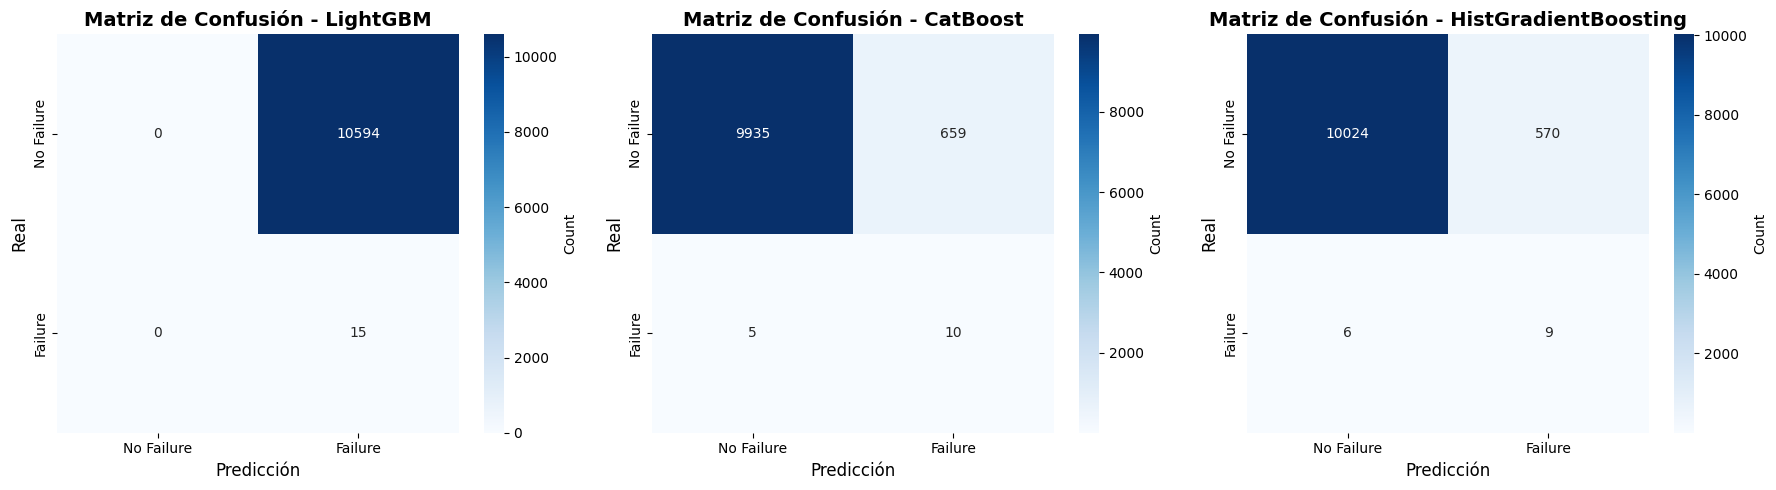

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report, recall_score, 
                              precision_score, roc_auc_score, cohen_kappa_score,
                              average_precision_score)
from sklearn.calibration import calibration_curve
import shap

# ============================================================================
# 1. MATRICES DE CONFUSIÓN
# ============================================================================

def plot_confusion_matrices(models_dict, X_test, y_test):
    """Plotea matrices de confusión para múltiples modelos"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, (name, model) in enumerate(models_dict.items()):
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                    cbar_kws={'label': 'Count'})
        axes[idx].set_title(f'Matriz de Confusión - {name}', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Predicción', fontsize=12)
        axes[idx].set_ylabel('Real', fontsize=12)
        axes[idx].set_xticklabels(['No Failure', 'Failure'])
        axes[idx].set_yticklabels(['No Failure', 'Failure'])
    
    plt.tight_layout()
    plt.show()

# Diccionario con los modelos
models = {
    'LightGBM': lgbopt,
    'CatBoost': catopt,
    'HistGradientBoosting': hgbopt
}

print("="*80)
print("1. MATRICES DE CONFUSIÓN (TEST SET)")
print("="*80)
plot_confusion_matrices(models, x_test, y_test)


2. FEATURE IMPORTANCE - SHAP VALUES

Calculando SHAP values para LightGBM...


c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\matplotlib\colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


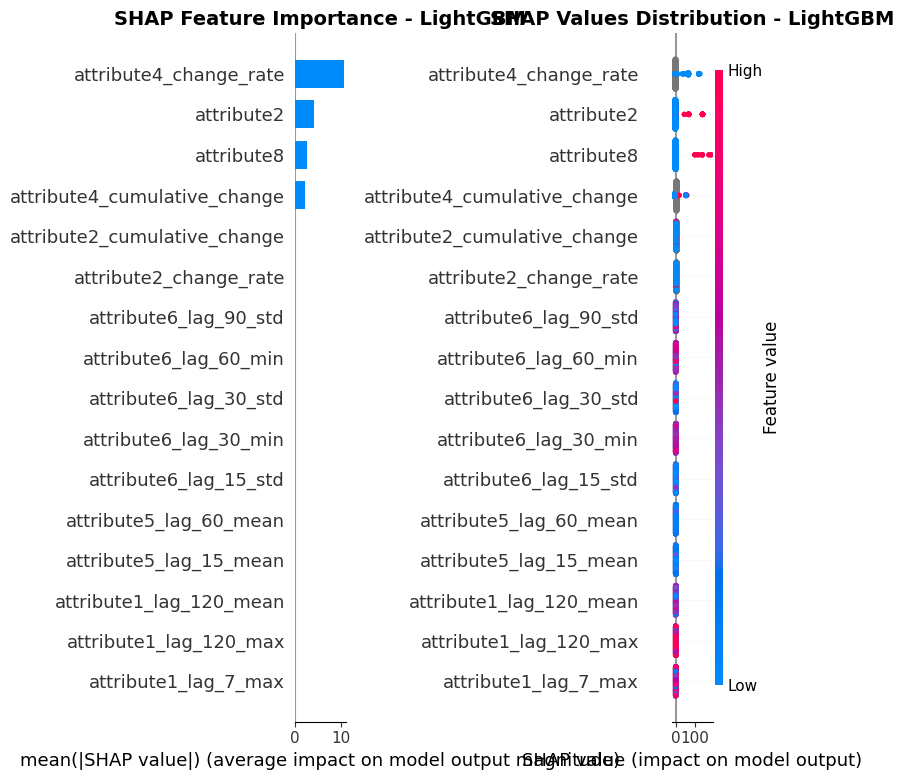


Calculando SHAP values para CatBoost...


c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\matplotlib\colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


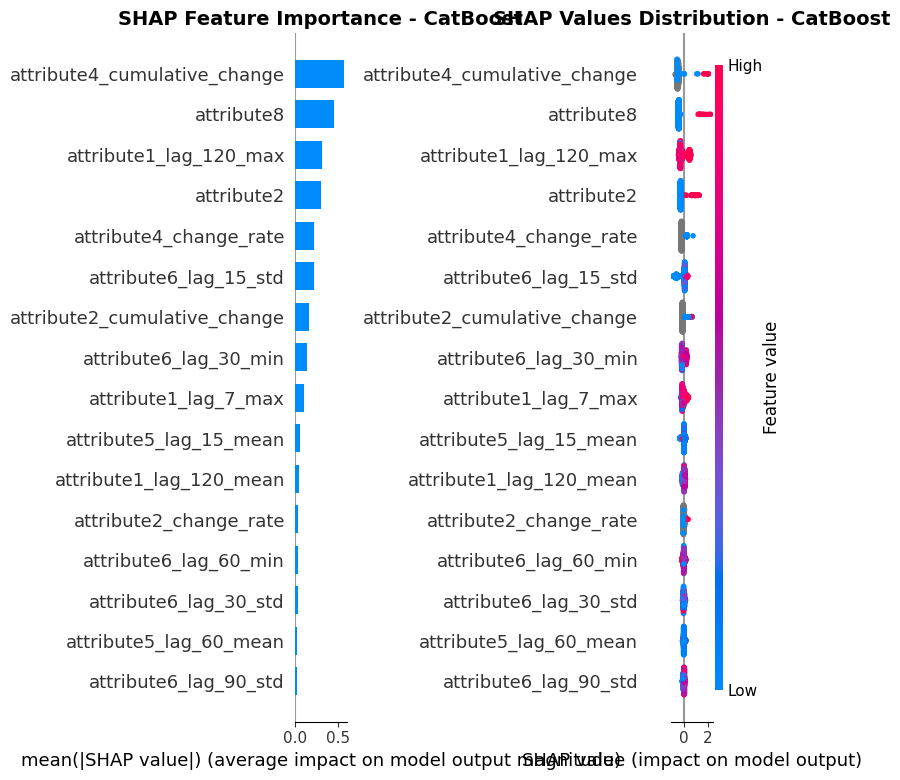


Calculando SHAP values para HistGradientBoosting...


c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\matplotlib\colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


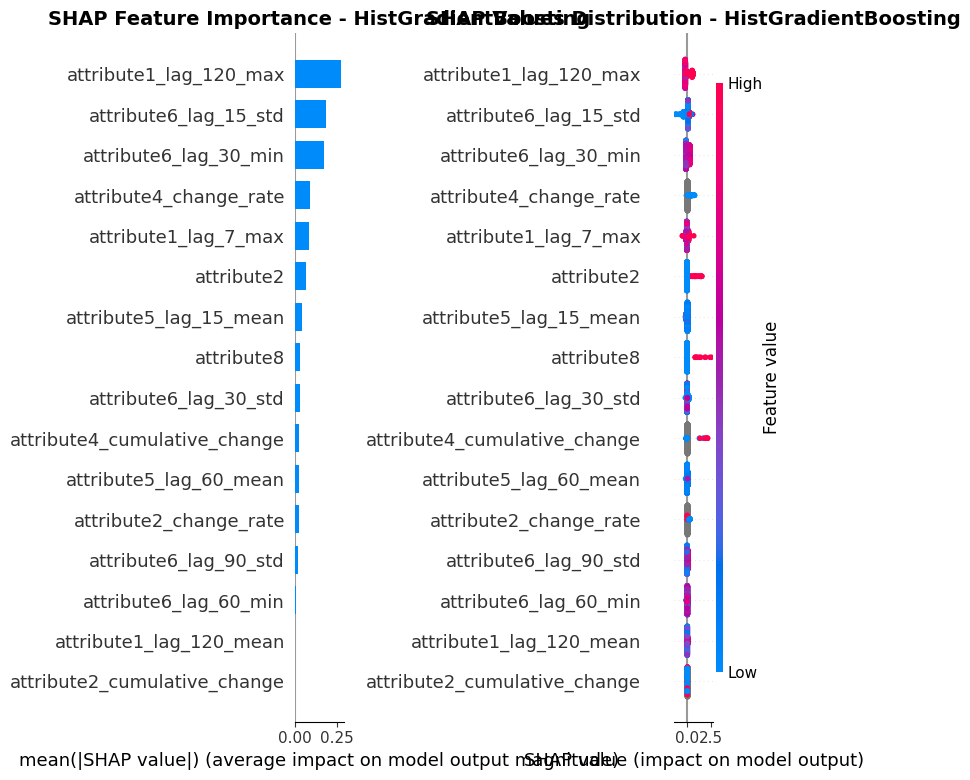

In [21]:
# ============================================================================
# 2. FEATURE IMPORTANCE CON SHAP VALUES
# ============================================================================

print("\n" + "="*80)
print("2. FEATURE IMPORTANCE - SHAP VALUES")
print("="*80)

def plot_shap_importance(model, X_sample, model_name, max_display=20):
    """Calcula y plotea SHAP values para un modelo"""
    print(f"\nCalculando SHAP values para {model_name}...")
    
    # Sample para eficiencia (SHAP es costoso)
    X_shap = X_sample.sample(min(1000, len(X_sample)), random_state=42)
    
    # Crear explainer
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)
    
    # Si es clasificación binaria, tomar clase positiva
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Summary plot (bar)
    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False, max_display=max_display)
    axes[0].set_title(f'SHAP Feature Importance - {model_name}', fontsize=14, fontweight='bold')
    
    # Summary plot (beeswarm)
    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_shap, show=False, max_display=max_display)
    axes[1].set_title(f'SHAP Values Distribution - {model_name}', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return shap_values, X_shap

# Calcular SHAP para cada modelo
shap_results = {}
for name, model in models.items():
    shap_values, X_shap = plot_shap_importance(model, x_train, name)
    shap_results[name] = {'shap_values': shap_values, 'X_shap': X_shap}

In [22]:
# ============================================================================
# 3. REPORTE DE RENDIMIENTO POR MUESTRA
# ============================================================================

print("\n" + "="*80)
print("3. REPORTE DE RENDIMIENTO POR MUESTRA")
print("="*80)

def evaluate_model_on_samples(model, samples_dict, model_name):
    """Evalúa un modelo en múltiples muestras y retorna métricas"""
    results = []
    
    for sample_name, (X_sample, y_sample) in samples_dict.items():
        # Predicciones
        y_pred = model.predict(X_sample)
        y_proba = model.predict_proba(X_sample)[:, 1]
        
        # Calcular métricas
        recall = recall_score(y_sample, y_pred)
        precision = precision_score(y_sample, y_pred, zero_division=0)
        pr_auc = average_precision_score(y_sample, y_proba)
        roc_auc = roc_auc_score(y_sample, y_proba)
        kappa = cohen_kappa_score(y_sample, y_pred)
        
        results.append({
            'Model': model_name,
            'Sample': sample_name,
            'Recall': recall,
            'Precision': precision,
            'PR-AUC': pr_auc,
            'ROC-AUC': roc_auc,
            'Kappa': kappa
        })
    
    return results

# Diccionario con todas las muestras
samples = {
    'Train': (x_train, y_train),
    'Test': (x_test, y_test),
    'OOS': (x_oos, y_oos),
    'OOT': (x_oot, y_oot)
}

# Evaluar todos los modelos
all_results = []
for model_name, model in models.items():
    print(f"\nEvaluando {model_name}...")
    results = evaluate_model_on_samples(model, samples, model_name)
    all_results.extend(results)

# Crear DataFrame con resultados
performance_df = pd.DataFrame(all_results)

# Mostrar resultados
print("\n📊 RESULTADOS DE RENDIMIENTO:")
print(performance_df.to_string(index=False))

# Tabla pivoteada para mejor visualización
print("\n📊 TABLA PIVOTADA POR MODELO:")
for metric in ['Recall', 'Precision', 'PR-AUC', 'ROC-AUC', 'Kappa']:
    pivot = performance_df.pivot(index='Sample', columns='Model', values=metric)
    print(f"\n{metric}:")
    print(pivot.round(4).to_string())

# Exportar a Excel
performance_df.to_excel('model_performance_report.xlsx', index=False)
print("\n✅ Resultados exportados a 'model_performance_report.xlsx'")


3. REPORTE DE RENDIMIENTO POR MUESTRA

Evaluando LightGBM...

Evaluando CatBoost...

Evaluando HistGradientBoosting...

📊 RESULTADOS DE RENDIMIENTO:
               Model Sample   Recall  Precision   PR-AUC  ROC-AUC    Kappa
            LightGBM  Train 1.000000   0.001022 0.001022 0.500000 0.000000
            LightGBM   Test 1.000000   0.001414 0.001414 0.500000 0.000000
            LightGBM    OOS 1.000000   0.000424 0.000424 0.500000 0.000000
            LightGBM    OOT 1.000000   0.000499 0.000499 0.500000 0.000000
            CatBoost  Train 0.807229   0.019148 0.138320 0.971928 0.035484
            CatBoost   Test 0.666667   0.014948 0.158220 0.879196 0.026547
            CatBoost    OOS 0.600000   0.003521 0.034187 0.932589 0.006163
            CatBoost    OOT 0.500000   0.001931 0.004793 0.606170 0.002854
HistGradientBoosting  Train 0.819277   0.023702 0.176132 0.967536 0.044172
HistGradientBoosting   Test 0.600000   0.015544 0.183949 0.844343 0.027623
HistGradientBoosting    O


4. CURVAS DE CALIBRACIÓN


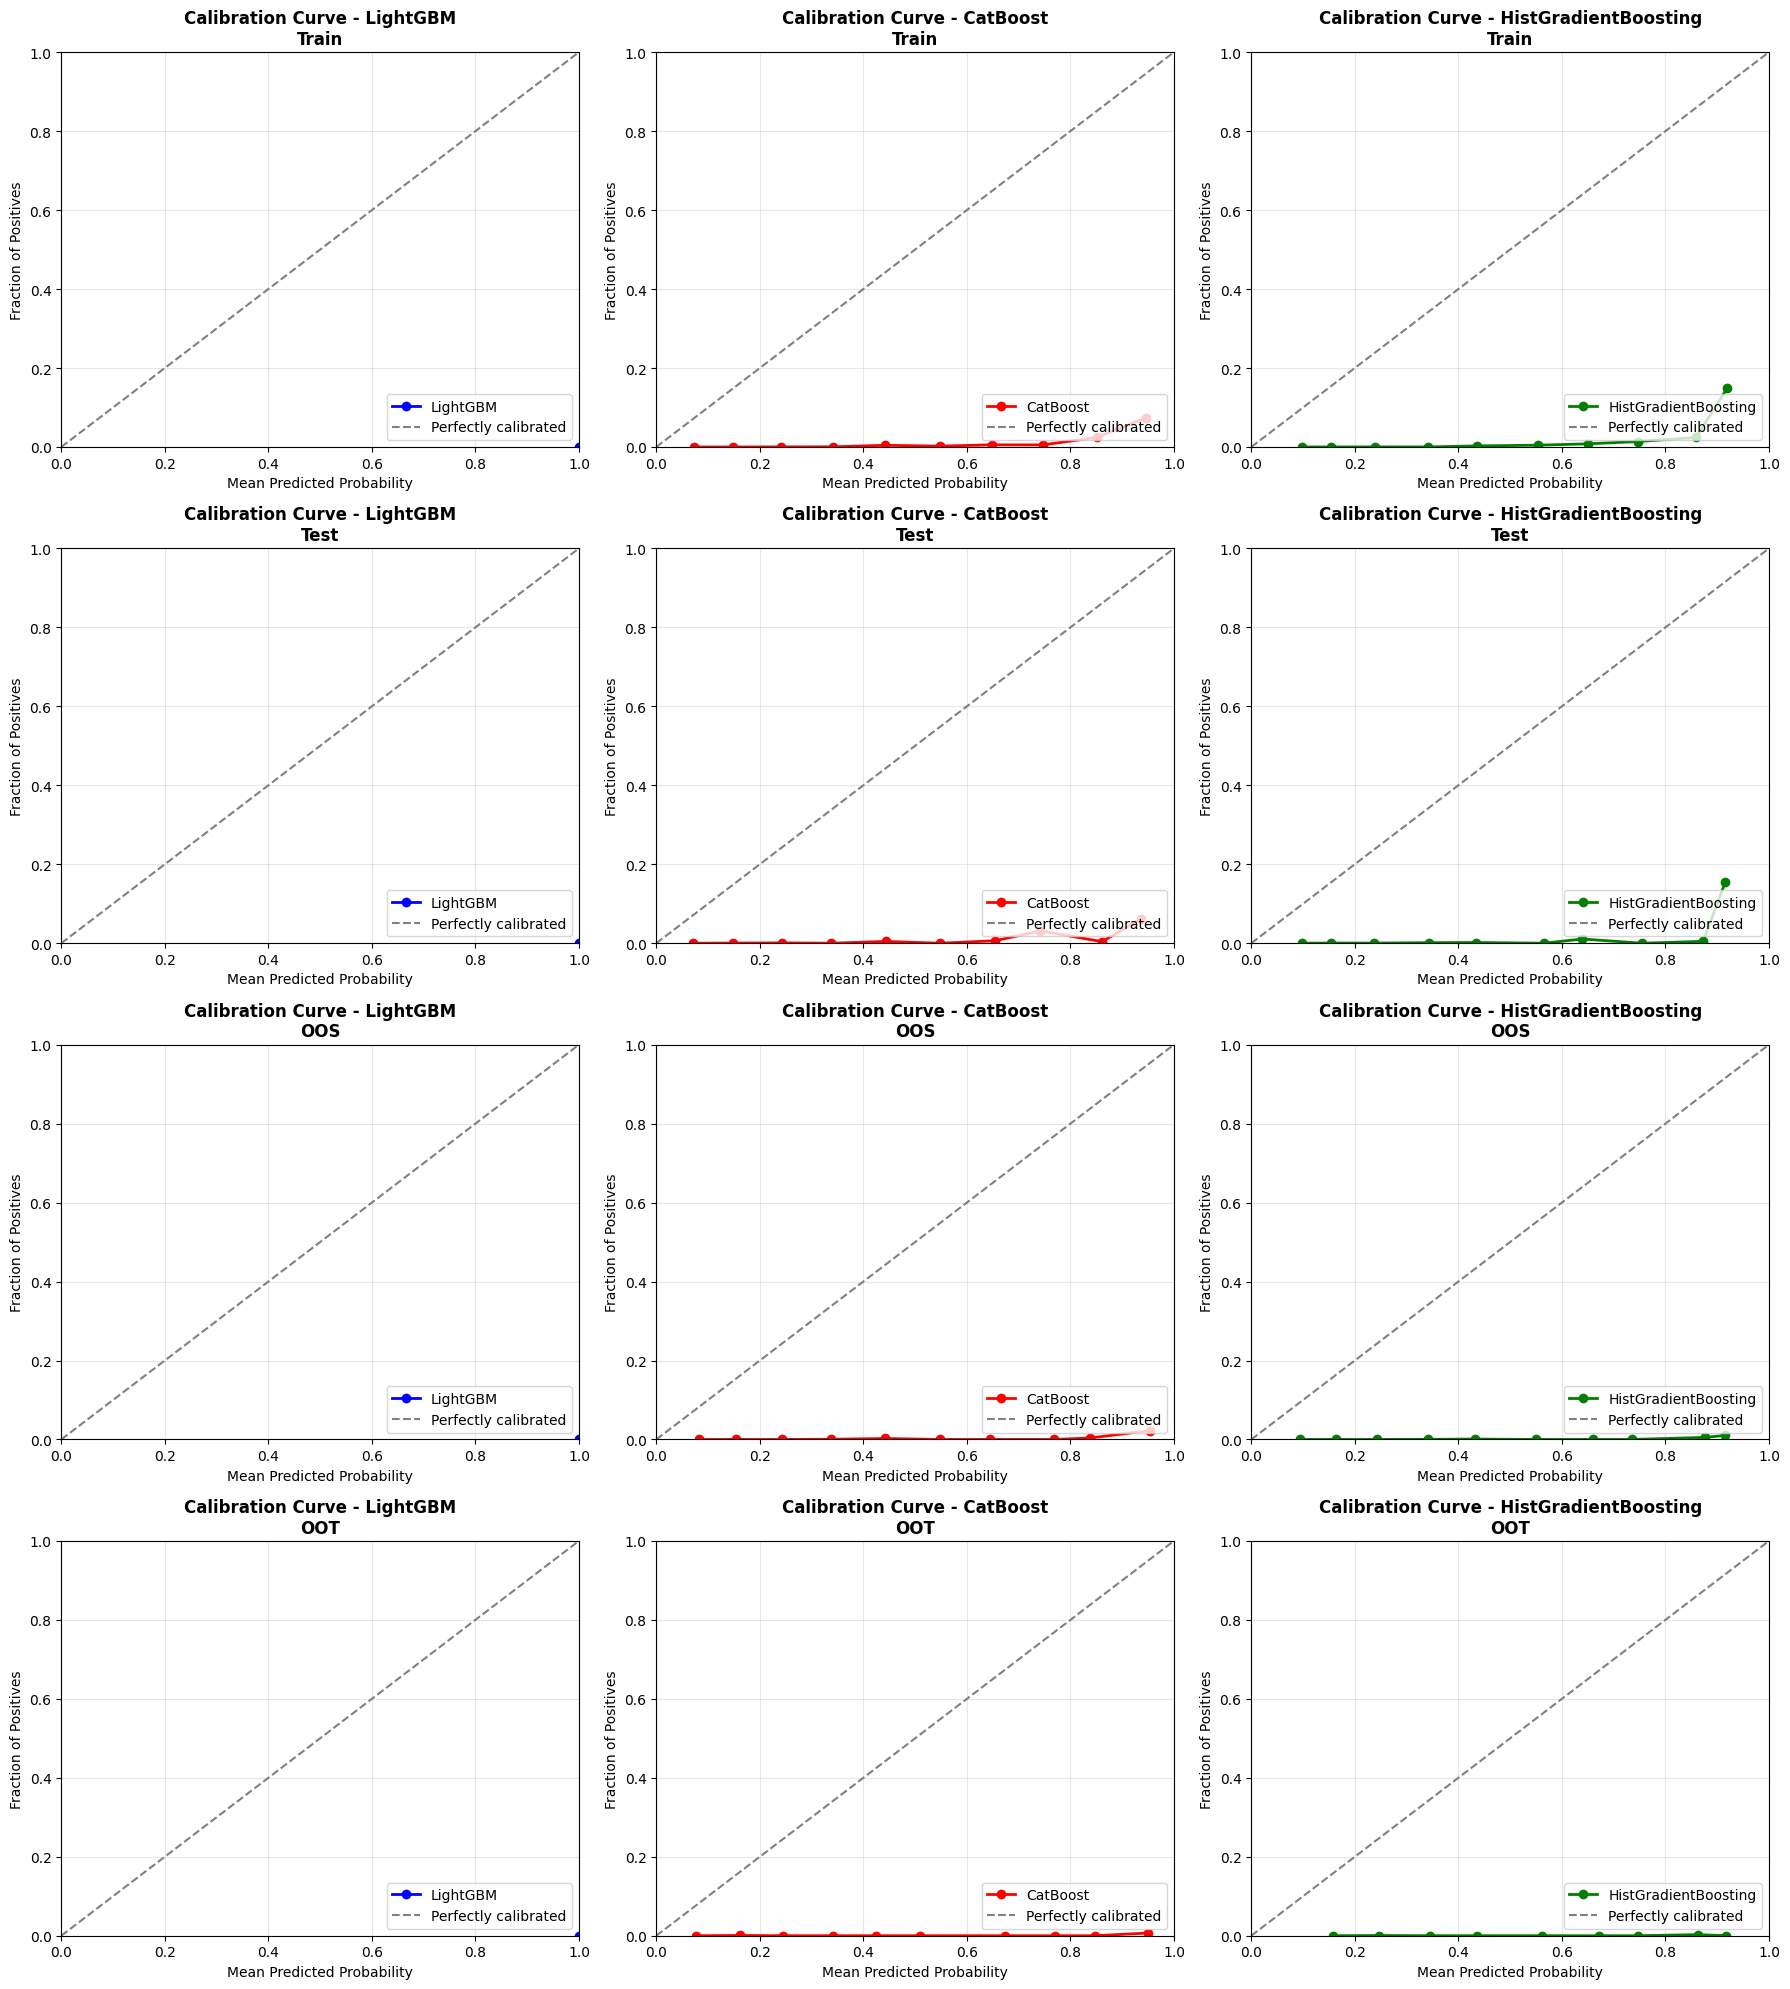

In [23]:
# ============================================================================
# 4. CURVAS DE CALIBRACIÓN
# ============================================================================

print("\n" + "="*80)
print("4. CURVAS DE CALIBRACIÓN")
print("="*80)

def plot_calibration_curves(models_dict, samples_dict):
    """Plotea curvas de calibración para múltiples modelos y muestras"""
    n_samples = len(samples_dict)
    fig, axes = plt.subplots(n_samples, 3, figsize=(18, 5*n_samples))
    
    if n_samples == 1:
        axes = axes.reshape(1, -1)
    
    colors = ['blue', 'red', 'green']
    
    for row_idx, (sample_name, (X_sample, y_sample)) in enumerate(samples_dict.items()):
        for col_idx, (model_name, model) in enumerate(models_dict.items()):
            ax = axes[row_idx, col_idx]
            
            # Obtener probabilidades predichas
            y_proba = model.predict_proba(X_sample)[:, 1]
            
            # Calcular curva de calibración
            fraction_of_positives, mean_predicted_value = calibration_curve(
                y_sample, y_proba, n_bins=10, strategy='uniform'
            )
            
            # Plotear
            ax.plot(mean_predicted_value, fraction_of_positives, 
                   marker='o', linewidth=2, label=f'{model_name}', color=colors[col_idx])
            ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
            
            ax.set_xlabel('Mean Predicted Probability', fontsize=10)
            ax.set_ylabel('Fraction of Positives', fontsize=10)
            ax.set_title(f'Calibration Curve - {model_name}\n{sample_name}', 
                        fontsize=12, fontweight='bold')
            ax.legend(loc='lower right')
            ax.grid(alpha=0.3)
            ax.set_xlim([0, 1])
            ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()

# Plotear curvas de calibración
plot_calibration_curves(models, samples)


RESUMEN VISUAL: COMPARACIÓN DE MODELOS


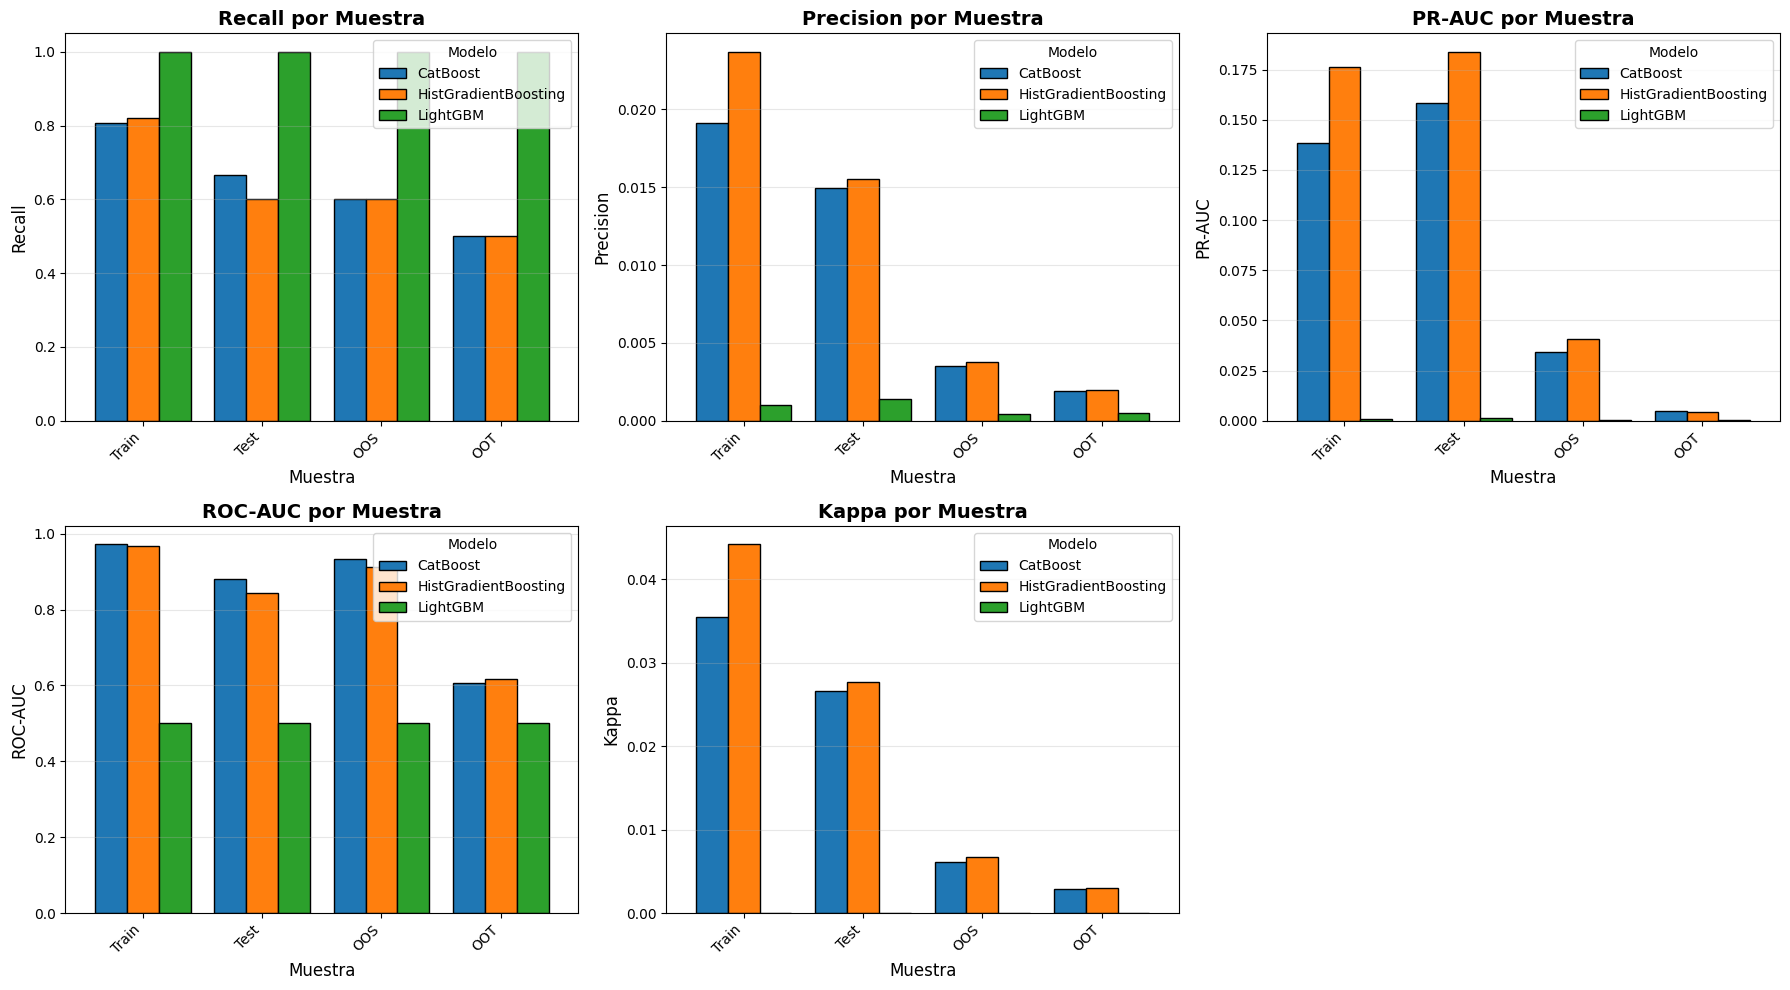


✅ Evaluación completa finalizada


In [24]:
# ============================================================================
# RESUMEN VISUAL: COMPARACIÓN DE MODELOS
# ============================================================================

print("\n" + "="*80)
print("RESUMEN VISUAL: COMPARACIÓN DE MODELOS")
print("="*80)

# Gráfico de barras comparativo
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics = ['Recall', 'Precision', 'PR-AUC', 'ROC-AUC', 'Kappa']
samples_list = ['Train', 'Test', 'OOS', 'OOT']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Preparar datos para el gráfico
    metric_data = performance_df.pivot(index='Sample', columns='Model', values=metric)
    metric_data = metric_data.reindex(samples_list)
    
    # Plotear
    metric_data.plot(kind='bar', ax=ax, width=0.8, edgecolor='black')
    ax.set_title(f'{metric} por Muestra', fontsize=14, fontweight='bold')
    ax.set_xlabel('Muestra', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.legend(title='Modelo', loc='best')
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Remover subplot extra
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

print("\n✅ Evaluación completa finalizada")

In [25]:
## Siguientes pasos